# Artificial Neural Network

In this notebook, we will build an Artificial Neural Network (ANN)
using TensorFlow 2.0 to predict whether a bank customer will leave
the bank based on their personal and financial information.

We will use the `Churn_Modelling.csv` dataset, which contains
10,000 records of bank customers along with a label indicating
whether each customer stayed with the bank (`0`) or left it (`1`).

## Workflow
1. Import the required libraries.
2. Preprocess the dataset.
3. Build the ANN model.
4. Train the model.
5. Evaluate the model.
6. Make predictions.

## Importing the Libraries

We start by importing the main libraries needed throughout the notebook:

- **NumPy** for numerical operations, mathematical computations, and array manipulation.
- **Pandas** for loading, processing, and analyzing the dataset.
- **TensorFlow** for building, compiling, and training the Artificial Neural Network (ANN).
- **Matplotlib** for creating basic data visualizations and plots.
- **Seaborn** for creating statistical visualizations and enhancing the appearance of charts.

In [72]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
tf.__version__

'2.20.0'

## Part 1 - Data Preprocessing

Before feeding our data into the neural network, we need to
prepare it properly. This includes loading the dataset, encoding
categorical variables into numerical values, splitting the data
into training and test sets, and scaling the features so the
network can learn efficiently.

### Importing the dataset

We load the `Churn_Modelling.csv` file into a Pandas DataFrame.
We then separate the features (`X`) from the target variable (`y`):

- `X` contains all the relevant customer information, starting
  from the "Credit Score" column and excluding the last column
  ("Exited"), since the first three columns (Row Number,
  Customer ID, Surname) are not useful predictors.
- `y` contains the target variable, "Exited", which indicates
  whether the customer left the bank (1) or stayed (0).

In [74]:
dataset = pd.read_csv('Churn_Modelling.csv')
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [75]:
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [76]:
print(y)

[1 0 1 ... 1 1 0]


### Exploring Feature Correlations

Before encoding and training, it's useful to explore the
relationships between the numerical features and the target
variable (`Exited`), using a correlation heatmap.

- Values close to **+1** mean a strong positive correlation
  (as one feature increases, so does the other).
- Values close to **-1** mean a strong negative correlation.
- Values close to **0** mean little to no linear relationship.

Note that we only include the numerical columns here — `Geography`
and `Gender` are excluded since they are categorical, along with
`RowNumber`, `CustomerId`, and `Surname`, which are just
identifiers and not useful for analysis.

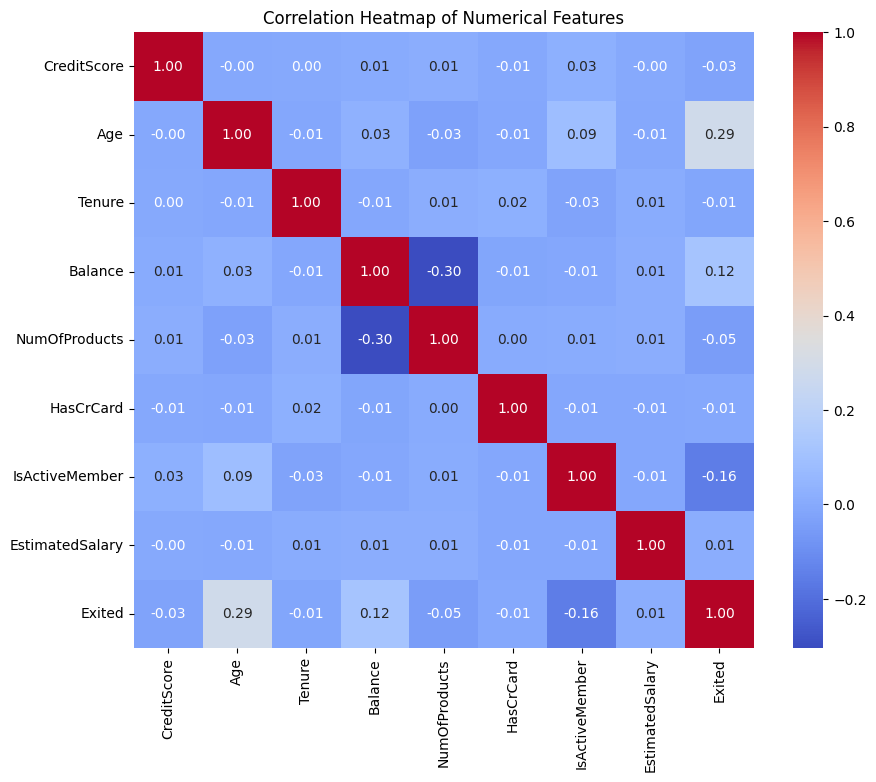

In [77]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                 'EstimatedSalary', 'Exited']

plt.figure(figsize=(10, 8))
sns.heatmap(dataset[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Encoding categorical data

Our dataset contains two categorical (text-based) columns:
"Gender" and "Geography". Since neural networks only work with
numerical data, we need to convert these columns into numbers
before training the model.



##### Label Encoding the "Gender" column

The "Gender" column has only two categories (Male/Female), so we
use Label Encoding to convert it into binary values (0 and 1).

In [78]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

In [79]:
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


#### One Hot Encoding the "Geography" column

The "Geography" column has three categories (France, Spain,
Germany). Since there's no ordinal relationship between them, we
use One Hot Encoding instead of Label Encoding. This creates a
separate binary column for each country, avoiding any false
numerical ordering between the categories.

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [81]:
print(X)

[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


### Splitting the dataset into the Training set and Test set

We split our data into a training set (80%) and a test set (20%).
The model will learn from the training set, and we will later
evaluate its performance on the unseen test set to check how well
it generalizes to new data.

In [82]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Feature Scaling

Feature Scaling is essential for training neural networks, as it
helps the model converge faster and perform better. We apply
Standardization using `StandardScaler`, which transforms the
features so they have a mean of 0 and a standard deviation of 1.

Note that we fit the scaler only on the training set and then use
it to transform both the training and test sets, to avoid data
leakage.

In [83]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [84]:
print(X_train)

[[-1.01460667 -0.5698444   1.74309049 ...  0.64259497 -1.03227043
   1.10643166]
 [-1.01460667  1.75486502 -0.57369368 ...  0.64259497  0.9687384
  -0.74866447]
 [ 0.98560362 -0.5698444  -0.57369368 ...  0.64259497 -1.03227043
   1.48533467]
 ...
 [ 0.98560362 -0.5698444  -0.57369368 ...  0.64259497 -1.03227043
   1.41231994]
 [-1.01460667 -0.5698444   1.74309049 ...  0.64259497  0.9687384
   0.84432121]
 [-1.01460667  1.75486502 -0.57369368 ...  0.64259497 -1.03227043
   0.32472465]]


## Part 2 - Building the ANN

Now that our data is ready, we can build the architecture of our
Artificial Neural Network using Keras' Sequential API. Our model
will consist of an input layer, two hidden layers, and an output
layer.

### Initializing the ANN

We initialize the ANN as a sequence of layers using the
`Sequential` class from Keras.

In [85]:
ann = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

We add the first fully-connected (Dense) hidden layer with 6
neurons and the ReLU (Rectified Linear Unit) activation function.
Keras automatically infers the shape of the input layer from the
training data.

In [86]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Adding the second hidden layer

We add a second hidden layer, also with 6 neurons and ReLU
activation, to increase the model's capacity to learn complex
patterns in the data.

In [87]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Adding the output layer

Since we're solving a binary classification problem (customer
stays or leaves), the output layer has a single neuron with a
Sigmoid activation function. The Sigmoid function outputs a
probability between 0 and 1, representing the likelihood that
the customer will leave the bank.

In [88]:
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

#Artificial Neural Network

- Input Layer
(12 Features)

        │
        ▼

- Hidden Layer 1
6 Neurons
Activation = ReLU

        │
        ▼

- Hidden Layer 2
6 Neurons
Activation = ReLU

        │
        ▼

- Output Layer
1 Neuron
Activation = Sigmoid

        │
        ▼

- Prediction:

0 → Customer Stays

1 → Customer Leaves

## Part 3 - Training the ANN

With the architecture defined, we now need to compile the model
and train it on our training data.

### Compiling the ANN

We compile the ANN by specifying:
- **Optimizer:** `adam`, an efficient stochastic gradient descent
  algorithm that adapts the learning rate during training.
- **Loss function:** `binary_crossentropy`, suitable for binary
  classification problems.
- **Metric:** `accuracy`, to monitor the model's performance
  during training.

In [89]:
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### Training the ANN on the Training set

We train the model on the training set for 100 epochs with a
batch size of 32. We also set `validation_split = 0.2`, which
means Keras will automatically set aside 20% of the training data
to evaluate the model after each epoch. This lets us monitor how
the model performs on unseen data during training, and helps us
detect overfitting later on.

We save the result of the training process in the `history`
variable, which we'll use afterward to plot the Loss and Accuracy
curves.

In [90]:
history = ann.fit(X_train, y_train, batch_size = 32, epochs = 100, validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7958 - loss: 0.5545 - val_accuracy: 0.7969 - val_loss: 0.4978
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4792 - val_accuracy: 0.7969 - val_loss: 0.4644
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4534 - val_accuracy: 0.7969 - val_loss: 0.4509
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4401 - val_accuracy: 0.7969 - val_loss: 0.4434
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4328 - val_accuracy: 0.7969 - val_loss: 0.4395
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4282 - val_accuracy: 0.7969 - val_loss: 0.4373
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4254 - val_accuracy: 0.7969 - val_loss: 0.4347
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4229 - val_accu

## Part 4 - Making the predictions and evaluating the model

Now that our ANN is trained, let's use it to make predictions and
evaluate how well it performs.

### Predicting the result of a single observation

**Homework**

Use our ANN model to predict if the customer with the following
informations will leave the bank:

- Geography: France
- Credit Score: 600
- Gender: Male
- Age: 40 years old
- Tenure: 3 years
- Balance: \$60000
- Number of Products: 2
- Does this customer have a credit card? Yes
- Is this customer an Active Member: Yes
- Estimated Salary: \$50000

So, should we say goodbye to that customer?

**Solution**

In [91]:
print(ann.predict(sc.transform([[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])) > 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[False]]


Therefore, our ANN model predicts that this customer stays in
the bank!

**Important note 1:** Notice that the values of the features were
all input in a double pair of square brackets. That's because
the "predict" method always expects a 2D array as the format of
its inputs. Putting our values into a double pair of square
brackets makes the input exactly a 2D array.

**Important note 2:** Notice also that the "France" country was
not input as a string in the last column but as "1, 0, 0" in the
first three columns. That's because the predict method expects
the one-hot-encoded values of the state, and as we saw in the
first row of the matrix of features X, "France" was encoded as
"1, 0, 0". Be careful to include these values in the first three
columns, since the dummy variables are always created first.

### Predicting the Test set results

We now use the trained model to predict the outcomes for the
entire test set. Since the Sigmoid output is a probability, we
apply a threshold of 0.5 to convert it into a binary prediction
(True = customer leaves, False = customer stays).

In [92]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


### Making the Confusion Matrix

Finally, we evaluate the model's performance using a Confusion
Matrix and the overall Accuracy Score, comparing the model's
predictions against the actual outcomes in the test set.

In [93]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[1514   81]
 [ 191  214]]


0.864

## Part 5 - Visualizing the Model's Performance

To better understand how our ANN performed, we'll visualize the
training process and evaluate the model using more detailed
metrics than accuracy alone. This includes plotting the Loss and
Accuracy curves, visualizing the Confusion Matrix as a heatmap,
and plotting the ROC Curve with its AUC score.

### Plotting the Training and Validation Loss/Accuracy

These plots show how the model's Loss and Accuracy evolved over
the 100 training epochs, for both the training set and the
validation set.

- If the training and validation curves stay close together, the
  model is generalizing well.
- If the training curve keeps improving while the validation
  curve gets worse (or plateaus), this is a sign of **overfitting**.

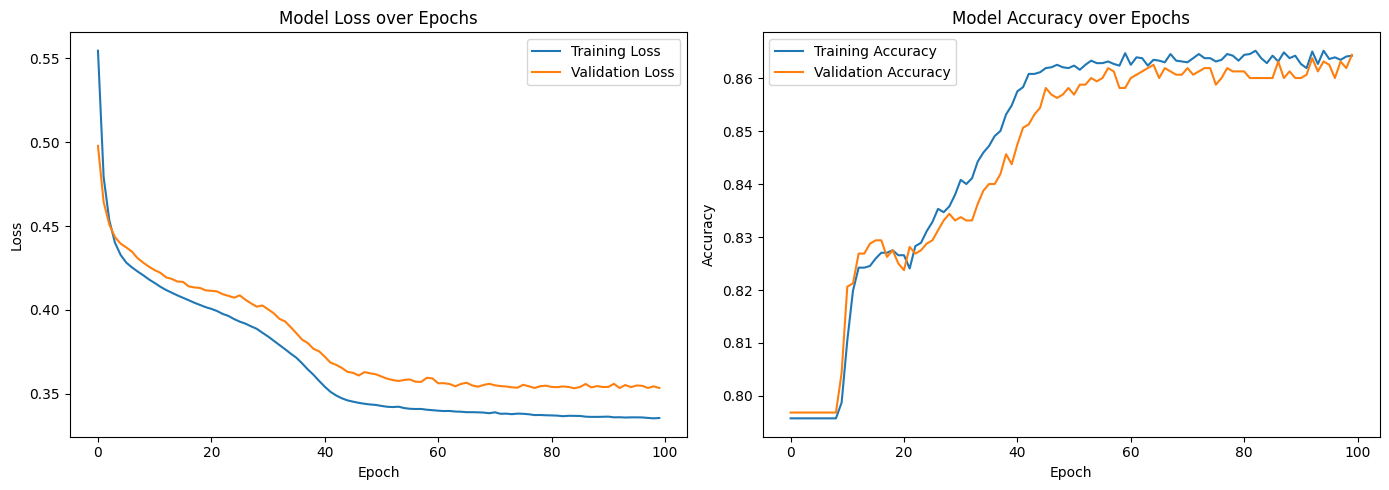

In [94]:
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Visualizing the Confusion Matrix as a Heatmap

Instead of just printing the raw numbers, we visualize the
Confusion Matrix as a heatmap using `seaborn`. This makes it much
easier to see how many customers were correctly and incorrectly
classified.

- **Top-left:** Customers who stayed and were correctly predicted
  to stay (True Negatives).
- **Top-right:** Customers who stayed but were incorrectly
  predicted to leave (False Positives).
- **Bottom-left:** Customers who left but were incorrectly
  predicted to stay (False Negatives).
- **Bottom-right:** Customers who left and were correctly
  predicted to leave (True Positives).

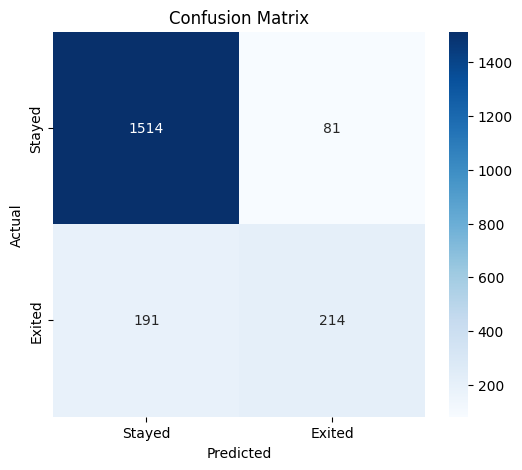

In [95]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Exited'],
            yticklabels=['Stayed', 'Exited'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Classification Report

The Confusion Matrix gives us the raw numbers, but the
**Classification Report** summarizes them into more meaningful
metrics for each class (Stayed / Exited):

- **Precision:** Out of all customers the model predicted would
  leave, how many actually left?
- **Recall:** Out of all customers who actually left, how many
  did the model correctly identify?
- **F1-score:** The harmonic mean of Precision and Recall — a
  balanced measure between the two.

These metrics are especially important here because our dataset
is **imbalanced** (far more customers stayed than left), so a
high overall accuracy alone can be misleading — the model might
be doing well on the "Stayed" class while performing poorly on
the "Exited" class.

In [96]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.89      0.95      0.92      1595
      Exited       0.73      0.53      0.61       405

    accuracy                           0.86      2000
   macro avg       0.81      0.74      0.76      2000
weighted avg       0.86      0.86      0.86      2000



### Plotting the ROC Curve and AUC Score

The Confusion Matrix and Accuracy Score depend on a fixed
threshold (0.5). The **ROC Curve** shows how the model performs
across *all* possible thresholds, by plotting the True Positive
Rate against the False Positive Rate.

The **AUC (Area Under the Curve)** score summarizes this in a
single number between 0 and 1:
- **AUC = 1.0** → perfect classifier.
- **AUC = 0.5** → random guessing.

AUC is especially useful here because our dataset is
**imbalanced** (more customers stayed than left), so it gives a
more reliable picture of performance than accuracy alone.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step


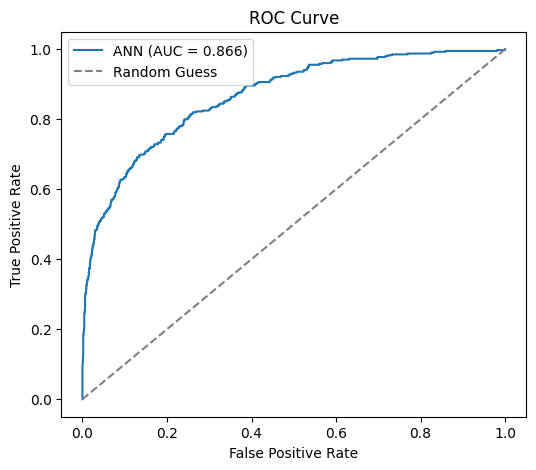

AUC Score: 0.8665


In [97]:
from sklearn.metrics import roc_curve, roc_auc_score

# We need the raw predicted probabilities, not the thresholded predictions
y_pred_proba = ann.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ANN (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print(f'AUC Score: {auc_score:.4f}')